# Review Intelligence Analysis

This notebook analyzes how review behavior relates to product sales performance in an e-commerce context.

Scope: two questions only, with measurable outputs and concise visual evidence suitable for formal submission.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

In [3]:
# Load base tables once

df_product = pd.read_csv("../data/products.csv")
df_review = pd.read_csv("../data/reviews.csv")

# Basic type cleaning
df_product["product_id"] = df_product["product_id"].astype(str)
df_review["product_id"] = df_review["product_id"].astype(str)

for col in ["price", "sold_count", "review_count", "rating_avg"]:
    df_product[col] = pd.to_numeric(df_product[col], errors="coerce").fillna(0)

df_product["revenue"] = df_product["price"] * df_product["sold_count"]

df_review["review_date"] = pd.to_datetime(df_review["review_date"], errors="coerce")
df_review["like_count"] = pd.to_numeric(df_review["like_count"], errors="coerce").fillna(0)
df_review["rating"] = pd.to_numeric(df_review["rating"], errors="coerce")
df_review["review_length"] = df_review["review_text"].astype(str).str.len()

## Question 1
### How did review activity dynamics evolve during 2020-2024, and how are they associated with product outcomes?

SMART objective

- Specific: measure temporal review activity and its association with product revenue/sales.
- Measurable: use monthly trend metrics and rank correlations.
- Achievable: computed from cleaned `reviews` and `products` tables.
- Relevant: review dynamics are operational signals for marketplace performance.
- Time-bound: explicitly centered on the 2020-2024 interval.

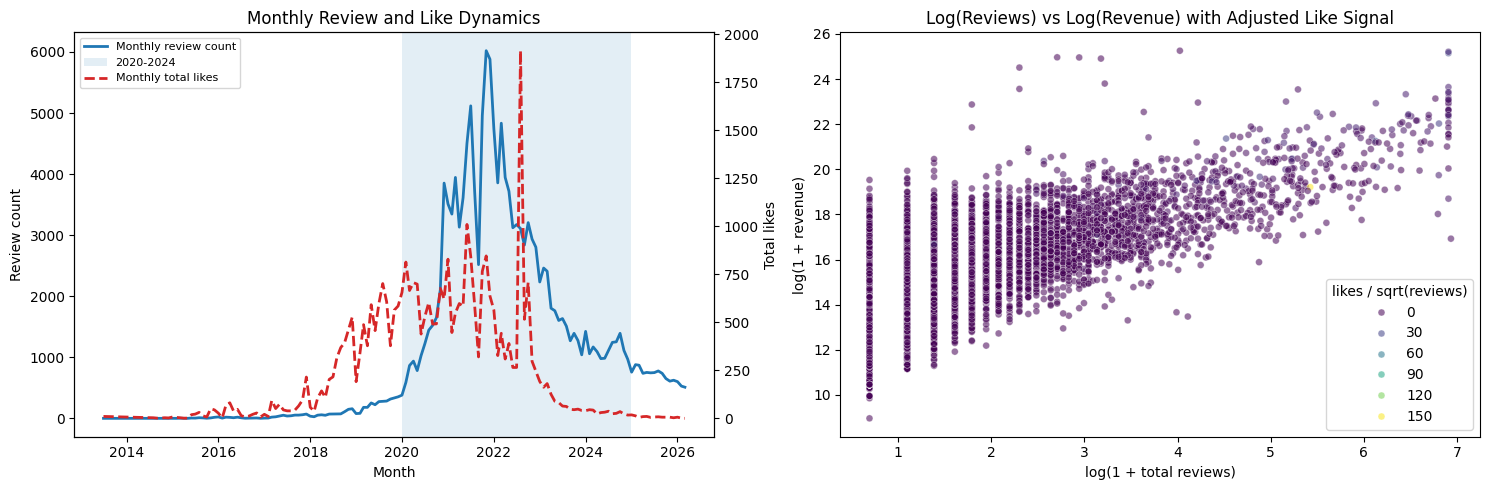

Spearman(log_reviews, log(revenue)): 0.654
Spearman(log_reviews, log(sold_count)): 0.831
Spearman(avg_review_length, log(sold_count)): 0.234
Spearman(likes/sqrt(reviews), log(revenue)): 0.459
Review volume share in 2020-2024: 90.5%


In [4]:
# Question 1: review dynamics and product outcomes (minimal version)

# Time features (no re-loading here)
current_date = df_review["review_date"].max()
df_review["days_since_review"] = (current_date - df_review["review_date"]).dt.days
df_review["review_month"] = df_review["review_date"].dt.tz_localize(None).dt.to_period("M").dt.to_timestamp()

# Monthly dynamics
monthly_review = (
    df_review.groupby("review_month")
    .agg(
        review_count=("review_id", "count"),
        total_like_count=("like_count", "sum"),
        avg_review_length=("review_length", "mean"),
    )
    .reset_index()
    .sort_values("review_month")
)

window = monthly_review[
    (monthly_review["review_month"] >= "2020-01-01")
    & (monthly_review["review_month"] <= "2024-12-31")
]
share_spike_period = (window["review_count"].sum() / max(1, monthly_review["review_count"].sum())) * 100

# Product-level features with less biased like metrics
product_review_features = (
    df_review.groupby("product_id")
    .agg(
        total_reviews=("review_id", "count"),
        avg_review_length=("review_length", "mean"),
        total_review_likes=("like_count", "sum"),
    )
    .reset_index()
)
product_review_features["log_total_reviews"] = np.log1p(product_review_features["total_reviews"])
product_review_features["log_total_likes"] = np.log1p(product_review_features["total_review_likes"])
product_review_features["likes_sqrt_adjusted"] = product_review_features["total_review_likes"] / np.sqrt(product_review_features["total_reviews"].clip(lower=1))

df_time_analysis = pd.merge(
    df_product[["product_id", "revenue", "sold_count", "price"]],
    product_review_features,
    on="product_id",
    how="inner",
)
df_time_analysis = df_time_analysis[df_time_analysis["revenue"] > 0].copy()

# Visualize (2 charts only)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Chart 1: time dynamics
axes[0].plot(monthly_review["review_month"], monthly_review["review_count"], linewidth=2, label="Monthly review count")
axes[0].axvspan(pd.Timestamp("2020-01-01"), pd.Timestamp("2024-12-31"), alpha=0.12, label="2020-2024")
ax2 = axes[0].twinx()
ax2.plot(monthly_review["review_month"], monthly_review["total_like_count"], linewidth=2, linestyle="--", color="tab:red", label="Monthly total likes")
axes[0].set_title("Monthly Review and Like Dynamics")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Review count")
ax2.set_ylabel("Total likes")
ln1, lb1 = axes[0].get_legend_handles_labels()
ln2, lb2 = ax2.get_legend_handles_labels()
axes[0].legend(ln1 + ln2, lb1 + lb2, loc="upper left", fontsize=8)

# Chart 2: product-level association
sns.scatterplot(
    data=df_time_analysis,
    x="log_total_reviews",
    y=np.log1p(df_time_analysis["revenue"]),
    hue="likes_sqrt_adjusted",
    palette="viridis",
    alpha=0.55,
    s=25,
    ax=axes[1],
)
axes[1].set_title("Log(Reviews) vs Log(Revenue) with Adjusted Like Signal")
axes[1].set_xlabel("log(1 + total reviews)")
axes[1].set_ylabel("log(1 + revenue)")
if axes[1].get_legend() is not None:
    axes[1].get_legend().set_title("likes / sqrt(reviews)")

plt.tight_layout()
plt.show()

# Metrics for interpretation
corr_review_revenue = df_time_analysis["log_total_reviews"].corr(np.log1p(df_time_analysis["revenue"]), method="spearman")
corr_review_sold = df_time_analysis["log_total_reviews"].corr(np.log1p(df_time_analysis["sold_count"]), method="spearman")
corr_text_sold = df_time_analysis["avg_review_length"].corr(np.log1p(df_time_analysis["sold_count"]), method="spearman")
corr_like_adj_revenue = df_time_analysis["likes_sqrt_adjusted"].corr(np.log1p(df_time_analysis["revenue"]), method="spearman")

print(f"Spearman(log_reviews, log(revenue)): {corr_review_revenue:.3f}")
print(f"Spearman(log_reviews, log(sold_count)): {corr_review_sold:.3f}")
print(f"Spearman(avg_review_length, log(sold_count)): {corr_text_sold:.3f}")
print(f"Spearman(likes/sqrt(reviews), log(revenue)): {corr_like_adj_revenue:.3f}")
print(f"Review volume share in 2020-2024: {share_spike_period:.1f}%")

### INSIGHT
- Review Volume is a Strong Driver of Market Outcomes: The scatter plot and high Spearman correlations (0.654 for log(revenue) and 0.831 for log(sold_count)) confirm a robust, positive relationship between the number of reviews and a product's commercial success. Review frequency acts as a primary trust signal for buyers.

- Review Length Yields Diminishing Returns: The length of the review text shows a positive but significantly weaker association with sales performance (Spearman = 0.234 for sold_count). Buyers seem to value the aggregate volume of feedback over the verbosity of individual reviews.

- High Temporal Concentration (2020-2024): Review activity is highly concentrated, with 90.5% of historical reviews generated between 2020 and 2024. The line chart reveals a massive surge peaking around late 2021/early 2022, likely driven by macroscopic e-commerce shifts or platform-specific growth initiatives.

- Likes are Decoupled and Potentially Noisy: The left chart highlights a massive, anomalous spike in "Total Likes" (red dashed line) around mid/late 2022, which occurs independently of the review count trend. This severe decoupling indicates that more reviews do not organically guarantee more helpfulness engagement (likes). Like metrics may be skewed by viral anomalies or inauthentic activity.

- Practical Implication: Strategic focus should be placed on incentivizing review quantity and overall participation rather than optimizing for long-form reviews or review "likes". Volume is a much more reliable and un-skewed predictor of revenue.

### Insight Focus (2020-2022): Potential Spam Review Screening with DBSCAN

This section isolates reviews in 2020-2022 and applies DBSCAN on behavioral/text features to flag anomalous review patterns.

Detection goal:
- Identify potential spam-like reviews for diagnostic insight.
- Quantify suspicious-share trend by month.
- Provide representative suspicious examples for qualitative checking.

2020-2022 spam screening summary (Duplicate Template Detection)
Total reviews in period: 100,830
Suspected spam reviews: 61,507 (61.00% of period)
Peak suspicious-share month: 2021-01 with share = 77.46%


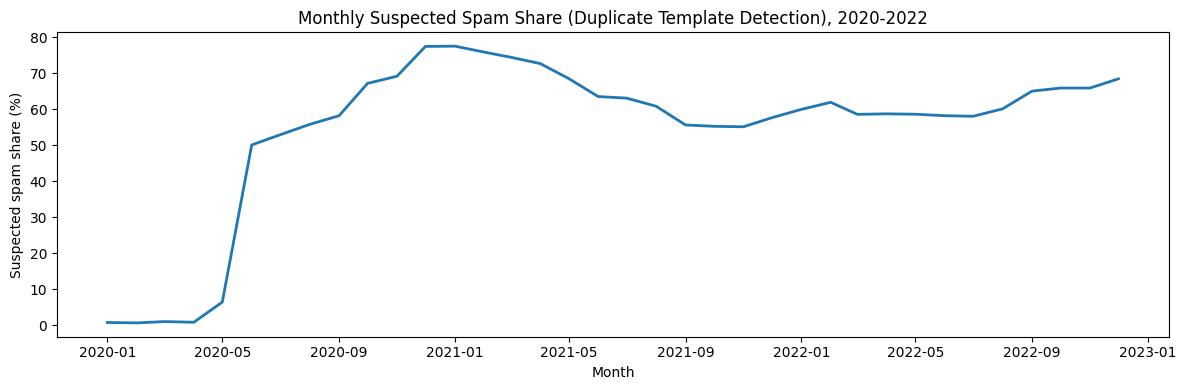

,template_text,template_count,unique_products,avg_rating,rating_std
4599,cực kì hài lòng,50469,3912,4.998811,0.034460
10139,hài lòng,7459,1853,4.057783,0.236770
608,bình thường,464,259,3.053879,0.261467
29364,sản phẩm tốt,379,260,4.934037,0.248546
6520,giao hàng nhanh,197,136,4.913706,0.299089
3253,chất lượng tốt,179,136,4.966480,0.180494
24717,rất hài lòng,142,116,4.929577,0.256763
12164,hàng tốt,139,119,4.920863,0.270928
28778,sản phẩm ok,126,117,4.873016,0.334284
32458,tuyệt vời,126,97,5.000000,0.000000


,review_date,rating,like_count,template_count,unique_products,review_text
0,2022-10-29 08:16:26+00:00,5,0,50469,3912,Cực kì hài lòng
1,2022-09-10 00:42:36+00:00,5,1,50469,3912,Cực kì hài lòng
2,2022-12-11 17:03:45+00:00,5,0,50469,3912,Cực kì hài lòng
3,2022-12-04 15:44:56+00:00,5,0,50469,3912,Cực kì hài lòng
4,2022-12-02 02:52:55+00:00,5,0,50469,3912,Cực kì hài lòng
5,2022-11-02 05:00:04+00:00,5,0,50469,3912,Cực kì hài lòng
6,2022-09-16 00:59:44+00:00,5,0,50469,3912,Cực kì hài lòng
7,2022-08-09 04:58:34+00:00,5,0,50469,3912,Cực kì hài lòng
8,2022-06-04 08:51:34+00:00,5,0,50469,3912,Cực kì hài lòng
9,2022-05-23 02:45:25+00:00,5,0,50469,3912,Cực kì hài lòng


In [5]:
# Insight cell: 2020-2022 spam-like review screening with Duplicate Template Detection

# Filter period 2020-2022
review_2020_2022 = df_review[
    (df_review["review_date"] >= "2020-01-01")
    & (df_review["review_date"] <= "2022-12-31")
] .copy()

review_2020_2022 = review_2020_2022.dropna(subset=["review_date", "review_text"]).copy()
review_2020_2022["review_text"] = review_2020_2022["review_text"].astype(str)

# Normalize text and build a template signature
review_2020_2022["clean_text"] = (
    review_2020_2022["review_text"]
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

review_2020_2022["template_text"] = (
    review_2020_2022["clean_text"]
    .str.replace(r"\d+", " <num> ", regex=True)
    .str.replace(r"[^\w\s]", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

review_2020_2022["text_len"] = review_2020_2022["clean_text"].str.len()
review_2020_2022 = review_2020_2022[review_2020_2022["text_len"] >= 8].copy()

# Compute template-level statistics
template_stats = (
    review_2020_2022.groupby("template_text")
    .agg(
        template_count=("review_id", "count"),
        unique_products=("product_id", "nunique"),
        avg_rating=("rating", "mean"),
        rating_std=("rating", "std"),
    )
    .reset_index()
)
template_stats["rating_std"] = template_stats["rating_std"].fillna(0)

# Duplicate-template risk rules
min_template_count = 5
min_cross_product = 3
max_rating_std = 0.35

template_stats["is_template_suspicious"] = (
    (template_stats["template_count"] >= min_template_count)
    & (template_stats["unique_products"] >= min_cross_product)
    & (template_stats["rating_std"] <= max_rating_std)
)

# Join template statistics back to review-level frame
dt_df = review_2020_2022.merge(
    template_stats,
    on="template_text",
    how="left",
)

dt_df["is_suspected_spam"] = dt_df["is_template_suspicious"].fillna(False)

# Monthly suspicious share
dt_df["review_month"] = (
    dt_df["review_date"]
    .dt.tz_localize(None)
    .dt.to_period("M")
    .dt.to_timestamp()
)

monthly_spam = (
    dt_df.groupby("review_month")
    .agg(
        total_reviews=("review_id", "count"),
        suspected_spam=("is_suspected_spam", "sum"),
    )
    .reset_index()
)
monthly_spam["suspected_spam_share"] = (
    monthly_spam["suspected_spam"]
    / monthly_spam["total_reviews"].replace(0, np.nan)
).fillna(0)

# Display quantitative summary
total_reviews_period = len(review_2020_2022)
total_suspected_spam = int(dt_df["is_suspected_spam"].sum())
spam_share = 100 * total_suspected_spam / max(1, total_reviews_period)

peak_row = monthly_spam.loc[monthly_spam["suspected_spam_share"].idxmax()]
print("2020-2022 spam screening summary (Duplicate Template Detection)")
print(f"Total reviews in period: {total_reviews_period:,}")
print(f"Suspected spam reviews: {total_suspected_spam:,} ({spam_share:.2f}% of period)")
print(
    f"Peak suspicious-share month: {peak_row['review_month'].strftime('%Y-%m')} "
    f"with share = {100 * peak_row['suspected_spam_share']:.2f}%"
)

# Plot suspicious-share dynamics
plt.figure(figsize=(12, 4))
plt.plot(monthly_spam["review_month"], 100 * monthly_spam["suspected_spam_share"], linewidth=2)
plt.title("Monthly Suspected Spam Share (Duplicate Template Detection), 2020-2022")
plt.xlabel("Month")
plt.ylabel("Suspected spam share (%)")
plt.tight_layout()
plt.show()

# Show top suspicious templates
top_templates = template_stats[template_stats["is_template_suspicious"]].copy()
top_templates = top_templates.sort_values(
    by=["template_count", "unique_products"],
    ascending=[False, False],
)

if not top_templates.empty:
    top_templates["template_text"] = top_templates["template_text"].str.slice(0, 120)
    display(top_templates[["template_text", "template_count", "unique_products", "avg_rating", "rating_std"]].head(10))
else:
    print("No suspicious duplicate templates were flagged by current thresholds.")

# Show sample suspicious reviews for manual validation
sample_cols = [
    "review_date",
    "rating",
    "like_count",
    "template_count",
    "unique_products",
    "review_text",
]
suspect_examples = dt_df[dt_df["is_suspected_spam"]].copy()
if not suspect_examples.empty:
    suspect_examples = suspect_examples.sort_values(
        by=["template_count", "unique_products", "rating_std"],
        ascending=[False, False, True],
    )
    suspect_examples["review_text"] = suspect_examples["review_text"].astype(str).str.slice(0, 180)
    display(suspect_examples[sample_cols].head(10).reset_index(drop=True))
else:
    print("No suspected spam reviews were flagged by current duplicate-template settings.")

- Massive Paradigm Shift in Mid-2020: The trend line illustrates a dramatic, structural shift in user behavior. The share of suspected spam/boilerplate reviews skyrocketed from near 0% in early 2020 to over 50% by May 2020, eventually peaking above 70%. Throughout 2021 and 2022, this metric plateaued at an alarmingly high baseline of 55% to 70%.

- The Anatomy of "Spam": The top flagged templates reveal that this "spam" is not inherently malicious. Instead, it consists of hyper-generic, low-effort positive phrases such as "cực kì hài lòng" (extremely satisfied - over 50,400 hits), "hài lòng" (satisfied), or "sản phẩm tốt" (good product). These templated texts are almost universally tied to perfect 5-star ratings, yielding a standard deviation near zero.

- Indicators of Platform-Driven Behavior: The statistical improbability of tens of thousands of users organically typing the exact same phrase across thousands of unique products points directly to platform interventions. This abrupt spike likely coincides with the introduction of auto-suggested quick replies (UI prompts) or incentivized review programs (e.g., "leave a review to earn coins"), where users submit the bare minimum text solely to claim rewards.

## Question 2
### Which review attributes matter globally and which vary by category context?

SMART objective

- Specific: compare global vs category-level effects of review attributes.
- Measurable: standardized linear coefficients, mean likes by rating, and top-liked review samples.
- Achievable: aggregate review features at product level and segment by category.
- Relevant: supports actionable review-quality strategy by category.
- Time-bound: evaluated on the current dataset snapshot.

Question 2 - Cell 1: Building global and category-level models

VIF diagnostics:


,Feature,VIF
0,log_review_volume,1.134
3,likes_sqrt_adjusted,1.122
1,rating_avg,1.072
2,avg_review_length,1.060


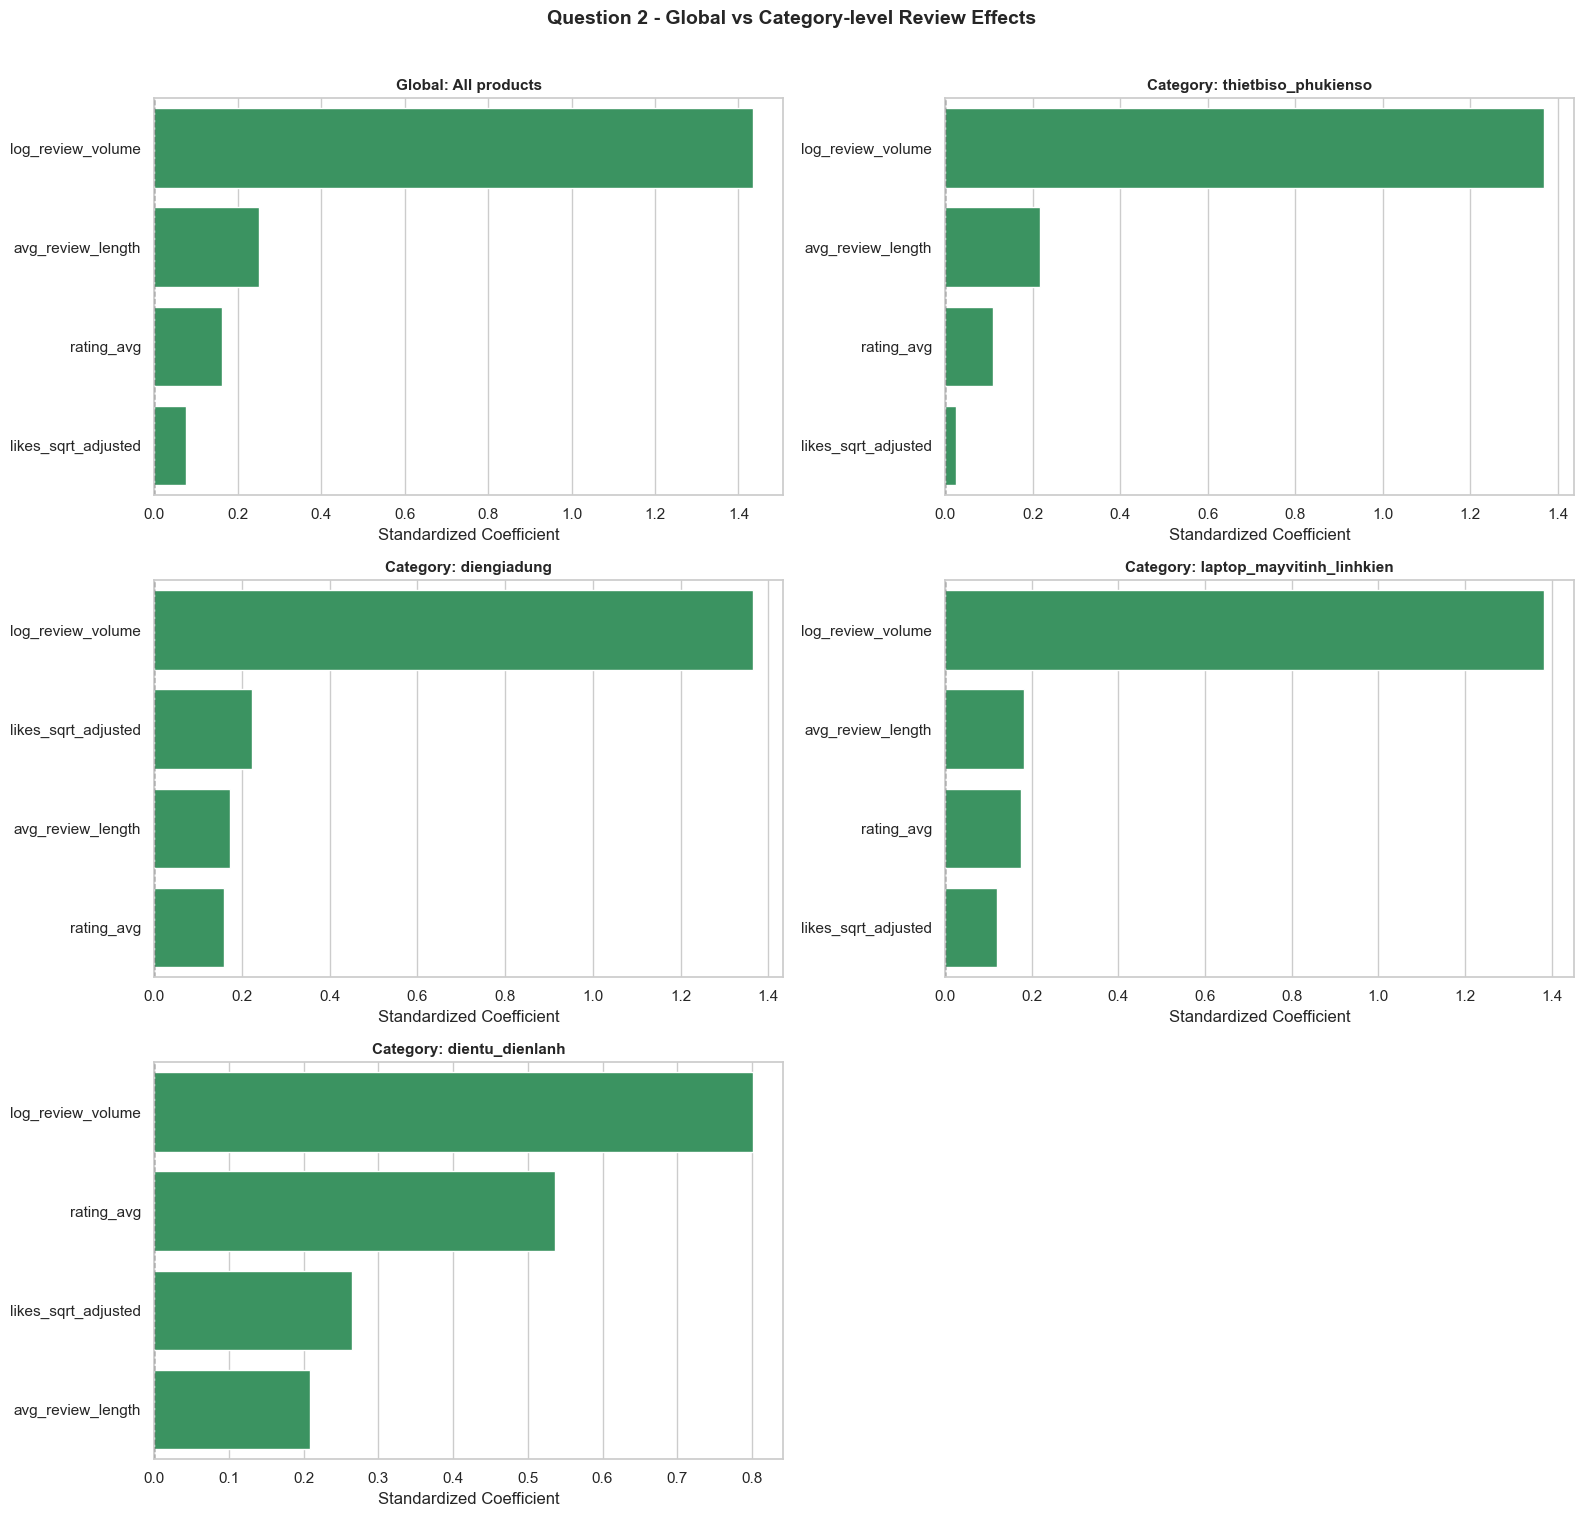

Cell 1 complete: variables available -> df_top_products, top1_names, local_weights_dict, vif_table


In [6]:
# Question 2 - Cell 1: global vs local feature effects (methodologically tightened)

print("Question 2 - Cell 1: Building global and category-level models")

# Standardize identifiers
review_df = df_review.copy()
product_df = df_product.copy()
review_df["product_id"] = review_df["product_id"].astype(str)
product_df["product_id"] = product_df["product_id"].astype(str)

# Numeric cleanup
for col in ["price", "sold_count", "rating_avg"]:
    product_df[col] = pd.to_numeric(product_df[col], errors="coerce").fillna(0)

review_df["like_count"] = pd.to_numeric(review_df["like_count"], errors="coerce").fillna(0)
review_df["review_length"] = review_df["review_text"].astype(str).str.len()

# Product-level targets
product_df["revenue"] = product_df["price"] * product_df["sold_count"]

# Review-derived features (avoid duplicate volume variables)
review_features = review_df.groupby("product_id", as_index=False).agg(
    total_reviews=("review_id", "count"),
    total_review_likes=("like_count", "sum"),
    avg_review_length=("review_length", "mean"),
)

# Fairer engagement metric across different review volumes
review_features["likes_sqrt_adjusted"] = (
    review_features["total_review_likes"]
    / np.sqrt(review_features["total_reviews"].replace(0, np.nan))
).fillna(0)

# Merge and prepare modeling frame
df_top_products = product_df.merge(review_features, on="product_id", how="inner")
df_top_products = df_top_products[df_top_products["revenue"] > 0].copy()
df_top_products["L2_ancestor"] = df_top_products["source_category"].fillna("unknown")

df_top_products["log_revenue"] = np.log1p(df_top_products["revenue"])
df_top_products["log_review_volume"] = np.log1p(df_top_products["total_reviews"])

features = [
    "log_review_volume",
    "rating_avg",
    "avg_review_length",
    "likes_sqrt_adjusted",
]
for c in features:
    df_top_products[c] = pd.to_numeric(df_top_products[c], errors="coerce").fillna(0)

# VIF diagnostics (without extra dependencies)
def compute_vif(df, feature_cols):
    vif_rows = []
    for f in feature_cols:
        y_col = df[f].values
        x_cols = [c for c in feature_cols if c != f]
        X = df[x_cols].values
        if X.shape[1] == 0:
            vif_rows.append((f, 1.0))
            continue
        model = LinearRegression()
        model.fit(X, y_col)
        r2 = model.score(X, y_col)
        vif = np.inf if r2 >= 0.999 else 1.0 / (1.0 - r2)
        vif_rows.append((f, vif))
    return pd.DataFrame(vif_rows, columns=["Feature", "VIF"]).sort_values("VIF", ascending=False)

vif_table = compute_vif(df_top_products, features)
print("\nVIF diagnostics:")
display(vif_table.round(3))


def get_linear_weights(df, feature_cols, target_col="log_revenue"):
    X = df[feature_cols]
    y = df[target_col]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    model = LinearRegression()
    model.fit(X_scaled, y)
    out = pd.DataFrame({"Attribute": feature_cols, "Weight": model.coef_})
    out["Impact_Magnitude"] = out["Weight"].abs()
    return out.sort_values("Impact_Magnitude", ascending=False).reset_index(drop=True)


global_weights = get_linear_weights(df_top_products, features)
top1_names = df_top_products["L2_ancestor"].value_counts().head(4).index.tolist()

local_weights_dict = {}
for cat in top1_names:
    df_cat = df_top_products[df_top_products["L2_ancestor"] == cat]
    if len(df_cat) >= 30:
        local_weights_dict[cat] = get_linear_weights(df_cat, features)

sns.set_theme(style="whitegrid")
num_plots = 1 + len(local_weights_dict)
rows, cols = int(np.ceil(num_plots / 2)), 2
fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
axes = np.array(axes).reshape(-1)


def plot_weights_on_ax(ax, df_w, title, is_global=False):
    colors = ["#2ca25f" if w > 0 else "#de2d26" for w in df_w["Weight"]]
    sns.barplot(
        data=df_w,
        x="Weight",
        y="Attribute",
        palette=colors,
        hue="Attribute",
        legend=False,
        ax=ax,
    )
    ax.axvline(x=0, color="black", linewidth=1, linestyle="--")
    ax.set_title(title if not is_global else f"Global: {title}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Standardized Coefficient")
    ax.set_ylabel("")


plot_weights_on_ax(axes[0], global_weights, "All products", is_global=True)
plot_idx = 1
for cat_name, df_w in local_weights_dict.items():
    plot_weights_on_ax(axes[plot_idx], df_w, f"Category: {cat_name}")
    plot_idx += 1
for i in range(plot_idx, len(axes)):
    fig.delaxes(axes[i])

plt.suptitle("Question 2 - Global vs Category-level Review Effects", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("Cell 1 complete: variables available -> df_top_products, top1_names, local_weights_dict, vif_table")

Question 2 - Cell 2: Comparing adjusted likes by category and rating

Category-level adjusted likes summary


,total_products,avg_adjusted_likes,median_adjusted_likes,avg_reviews_per_product
L2_ancestor,,,,
diengiadung,2645,0.52,0.0,24.72
laptop_mayvitinh_linhkien,1189,0.42,0.0,16.16
thietbiso_phukienso,6395,0.24,0.0,10.65
dientu_dienlanh,289,0.23,0.0,6.16



Median likes per review by star rating


rating,1,2,3,4,5
L2_ancestor,,,,,
diengiadung,0.0,0.0,0.0,0.0,0.0
dientu_dienlanh,0.0,0.0,0.0,0.0,0.0
laptop_mayvitinh_linhkien,0.0,0.0,0.0,0.0,0.0
thietbiso_phukienso,0.0,0.0,0.0,0.0,0.0


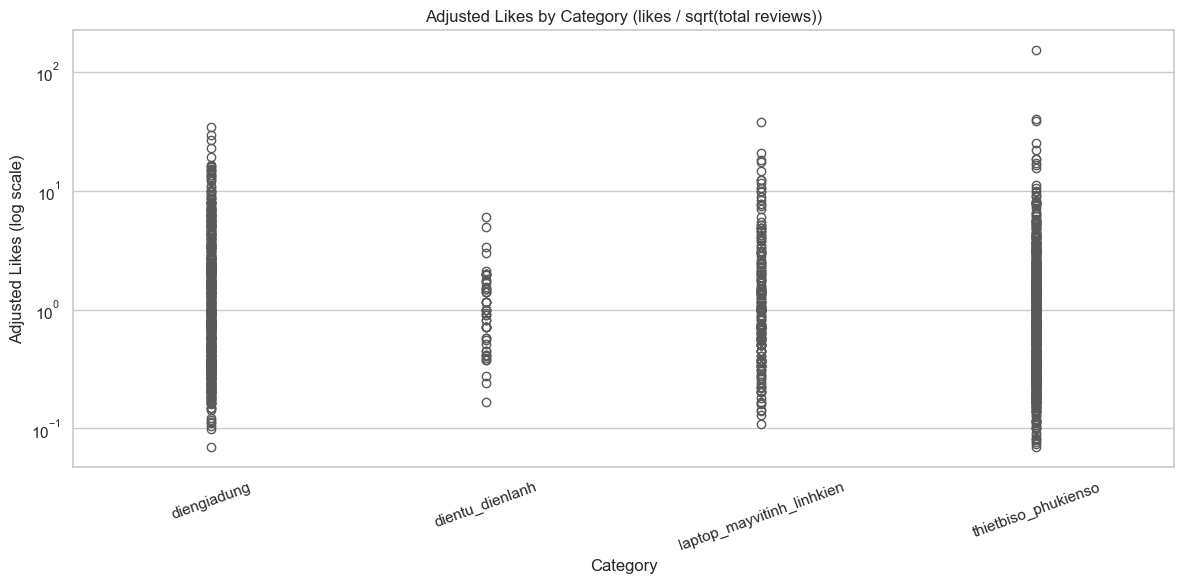

In [7]:
# Question 2 - Cell 2: adjusted likes by category and rating

print("Question 2 - Cell 2: Comparing adjusted likes by category and rating")

likes_summary = (
    df_top_products[df_top_products["L2_ancestor"].isin(top1_names)]
    .groupby("L2_ancestor")
    .agg(
        total_products=("product_id", "count"),
        avg_adjusted_likes=("likes_sqrt_adjusted", "mean"),
        median_adjusted_likes=("likes_sqrt_adjusted", "median"),
        avg_reviews_per_product=("total_reviews", "mean"),
    )
    .sort_values("avg_adjusted_likes", ascending=False)
)

print("\nCategory-level adjusted likes summary")
display(likes_summary.round(2))

df_review_extended = review_df.merge(
    product_df[["product_id", "source_category"]].rename(columns={"source_category": "product_source_category"}),
    on="product_id",
    how="left",
)
df_review_extended["L2_ancestor"] = df_review_extended["product_source_category"].fillna("unknown")
df_review_extended = df_review_extended[df_review_extended["L2_ancestor"].isin(top1_names)].copy()
df_review_extended["rating"] = pd.to_numeric(df_review_extended["rating"], errors="coerce")
df_review_extended["like_count"] = pd.to_numeric(df_review_extended["like_count"], errors="coerce").fillna(0)

rating_likes_corr = (
    df_review_extended.groupby(["L2_ancestor", "rating"])["like_count"]
    .median()
    .unstack()
)

print("\nMedian likes per review by star rating")
display(rating_likes_corr.round(2))

plot_df = df_top_products[df_top_products["L2_ancestor"].isin(top1_names)].copy()

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=plot_df,
    x="L2_ancestor",
    y="likes_sqrt_adjusted",
    hue="L2_ancestor",
    palette="Set2",
    legend=False,
)
plt.yscale("log")
plt.title("Adjusted Likes by Category (likes / sqrt(total reviews))")
plt.xlabel("Category")
plt.ylabel("Adjusted Likes (log scale)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [8]:
# Question 2 - Cell 3: top liked reviews by category

print("Question 2 - Cell 3: Extracting top liked reviews by category\n")

df_review_full = df_review.merge(
    df_product[["product_id", "product_name", "source_category"]].rename(columns={"source_category": "product_source_category"}),
    on="product_id",
    how="left",
)

df_review_full["L2_ancestor"] = df_review_full["product_source_category"].fillna("unknown")
df_top_reviews = df_review_full[df_review_full["L2_ancestor"].isin(top1_names)].copy()

df_top_reviews["like_count"] = pd.to_numeric(df_top_reviews["like_count"], errors="coerce").fillna(0).astype(int)
df_top_reviews["rating"] = pd.to_numeric(df_top_reviews["rating"], errors="coerce")

top5_reviews_per_cat = (
    df_top_reviews.sort_values(by=["L2_ancestor", "like_count"], ascending=[True, False])
    .groupby("L2_ancestor")
    .head(5)
)

for cat in top1_names:
    print(f"Category: {cat}")
    cat_reviews = top5_reviews_per_cat[top5_reviews_per_cat["L2_ancestor"] == cat].copy()

    if cat_reviews.empty:
        print("No review data for this category.\n")
        continue

    cat_reviews["Review_Text"] = cat_reviews["review_text"].astype(str).apply(
        lambda x: x[:180] + "..." if len(x) > 180 else x
    )
    cat_reviews["Product_Name"] = cat_reviews["product_name"].astype(str).apply(
        lambda x: x[:60] + "..." if len(x) > 60 else x
    )

    cat_reviews = cat_reviews.rename(columns={"rating": "Rating", "like_count": "Likes"})
    cols_to_show = ["Rating", "Likes", "Product_Name", "Review_Text"]
    display(cat_reviews[cols_to_show].reset_index(drop=True))
    print("-" * 90)

Question 2 - Cell 3: Extracting top liked reviews by category

Category: thietbiso_phukienso


,Rating,Likes,Product_Name,Review_Text
0,5,60,Adapter Sạc 1 Cổng USB Type-C 20W Apple,Cân nhắc lợi và hại khi mua bởi những lý do sa...
1,5,51,Adapter Sạc 1 Cổng USB Type-C 20W Apple,Có tem nhập khẩu Ngôi nhà Đức gì đó là được rồ...
2,1,48,Chuột Chơi Game Có Dây Logitech Proteus Spectr...,Sản phẩm mình mới nhận được phải nói là rất cũ...
3,5,47,Adapter Sạc 1 Cổng USB Type-C 20W Apple,Mình cũng lăn tăn trước khi order lắm nhưng mn...
4,3,41,Tai Nghe Nhét Tai Sony MDR-EX155AP - Hàng Chín...,"vừa nhận được hàng, mở ra thì bên trong đúng c..."


------------------------------------------------------------------------------------------
Category: diengiadung


,Rating,Likes,Product_Name,Review_Text
0,5,289,Nồi Chiên Không Dầu Điện Tử Lock&Lock EJF357BL...,Mình mua lúc trước tết. giá giảm còn 2tr2 thôi...
1,5,174,Máy Hút Bụi Cầm Tay Không Dây Damas XC628 - Ch...,"thực sự cũng không định mua hàng qua mang đâu,..."
2,5,144,Máy Làm Sữa Chua Lock&Lock EJY110SLV (1000ml) ...,Hôm nay tình cờ thấy Tiki sale máy làm sữa chu...
3,5,125,Máy Làm Sữa Chua Lock&Lock EJY110SLV (1000ml) ...,Làm xong đi giới thiệu bà chị bả mua liền xong...
4,3,110,Máy Cạo Râu Mạnh Mẽ Tiện Dụng Phong Cách SCW301U,Hàng thì hài lòng nhưng shiper mình k hài lòng...


------------------------------------------------------------------------------------------
Category: laptop_mayvitinh_linhkien


,Rating,Likes,Product_Name,Review_Text
0,1,73,TP-Link TL-WN822N - USB Wifi (high gain) chuẩ...,Mình là người làm kỹ thuật cũng có liên quan đ...
1,1,55,Thiết Bị Kích Sóng Wifi Xiaomi Pro - Đen - Hàn...,"Thứ nhất,sản phẩm không dùng được.Thứ hai,đội ..."
2,4,49,TP-Link TL-WR841N - Router Wifi Chuẩn N Tốc Đ...,Mình mua lần đầu lỗi rớt mạng đổi luôn. Sau kh...
3,3,47,Máy In Laser Đơn Năng Canon LBP 6030 - Hàng ch...,"Giao hàng nhanh, hàng chính hãng canon được sả..."
4,5,45,Phần mềm Microsoft 365 Personal | 12 tháng | ...,"ok, tôi cảm thấy thích thú khi đã gia hạn thêm..."


------------------------------------------------------------------------------------------
Category: dientu_dienlanh


,Rating,Likes,Product_Name,Review_Text
0,3,12,Android TV Box TX3 mini phiên bản 2020 Android...,Mẫu này cài android 9.0 nhé không phải android...
1,5,10,Tủ lạnh mini Kemin Chính hãng 10L,Tủ lạnh hoạt động tốt như mô tả. Gia đình chún...
2,5,6,Android tivi box x96 max 4GB RAM wifi kép có đ...,sản phẩm tốt. nhưng dịch vụ rất tệ tặng chuột ...
3,5,6,Tủ Lạnh Inverter Sharp SJ-FX688VG-BK (605L) - ...,Rất ok máy chạy rats êm. Tủ to đựng được rất n...
4,1,5,Android TV Box TX3 mini phiên bản 2020 Android...,Sản phẩm rất tệ. Bật wifi miết ko được. Điều k...


------------------------------------------------------------------------------------------


### INSIGHT
- The Overwhelming Dominance of Review Volume: The standardized coefficient charts explicitly demonstrate that log_review_volume is the vastly superior predictor of product revenue. This holds true globally and consistently across all four major categories, cementing review frequency as the primary market signal driving conversion.

- Marginal Contributions of Rating and Length: While rating_avg and avg_review_length exhibit positive associations, their effect sizes are relatively minor. Notably, category-specific nuances exist: in the Electronics & Refrigeration (dientu_dienlanh) category, the average rating carries significantly more weight compared to other sectors, suggesting that consumers prioritize qualitative assurance more heavily for higher-ticket appliances.

- Highly Skewed and Sparse Nature of "Likes": The log-scaled Boxplot and median metrics confirm that engagement via "Likes" is highly sparse (median ≈ 0). The distribution is heavily skewed by extreme outliers. Most reviews receive zero engagement, while a select few "viral" reviews amass hundreds of likes (e.g., 289 likes for an air fryer review).

- The Anatomy of "Top Liked" Reviews: Qualitative inspection of the most liked reviews reveals that users actively endorse not only detailed 5-star experiences but also highly critical 1-star reviews. High like counts often highlight community consensus around a product's critical flaws (e.g., defective routers, used conditions) or exceptional benefits. Thus, "Likes" measure community resonance rather than pure product quality.